# **Análise comparativa de modelos**

## **Visão Geral do Notebook**

Neste notebook, buscamos prever a eficiência do sono utilizando o conjunto de dados **Sleep Efficiency** disponível no **[Kaggle](https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency/data)**. A metodologia seguiu etapas de obtenção, preparação e modelagem dos dados, começando pela limpeza e transformação, incluindo imputação de valores faltantes, codificação de variáveis categóricas, normalização de variáveis numéricas e tratamento de outliers.

Em seguida, treinamos e comparamos quatro modelos preditivos: Regressão Linear, Random Forest, Support Vector Regressor (SVR) e K-Nearest Neighbors (KNN), usando validação cruzada para garantir a robustez dos resultados. Este estudo visa identificar o modelo mais eficaz para prever a eficiência do sono com base em características relacionadas ao estilo de vida e saúde dos indivíduos.

A **metodologia** adotada foi estruturada nas seguintes etapas:

 - **Obtenção de Dados**
 - **Padronização de Variáveis**
 - **Preparação dos Dados**
 - **Modelagem Preditiva**
 - **Validação dos Modelos**

## **Metodologia**

**Obtenção de Dados:**

Nesta etapa, foi configurado o ambiente com a importação das bibliotecas do Python necessárias para preparação e modelagem, como Pandas, Numpy, Scikit-Learn e Scipy. Em seguida, o conjunto de dados **Sleep Efficiency** foi carregado, apresentada uma caracterização geral do conjunto e carregado o dicionário de dados.


**Padronização de Variáveis:**

Nesta etapa, padronizamos o DataFrame convertendo variáveis categóricas para o tipo `category`, transformando colunas de data e hora para o tipo datetime e criando novas colunas separadas para data e hora, e convertendo valores de consumo de álcool de onças para gramas. Essas mudanças organizam e preparam os dados para uma análise mais eficiente.

Nesta etapa, realizou-se a padronização das variáveis do conjunto de dados. As variáveis categóricas foram convertidas para o tipo `category`. As variáveis de data e hora foram convertida para o tipo `datetime`, gerando novas variáveis. Os valores de consumo de álcool foram convertidos da unidade de medida onça (oz) para grama (g). Além disso, algumas colunas não relevantes para o modelo foram excluídas, e as demais foram renomeadas para o padrão `snake_case`.



**Preparação de Dados:**

Esta etapa envolve a limpeza e transformação de dados necessárias para garantir que os dados estejam prontos para a modelagem. Isso inclui:

* A preparação dos dados envolve a limpeza e transformação necessárias para garantir que os dados estejam prontos para a modelagem. Isso inclui:

  - **Tratamento de outilers:** Os outliers foram tratados utilizando o **Método de Capping** baseado no Intervalo Interquartil (IQR), que limita os valores dos dados dentro de intervalos definidos para evitar distorções. Esse método estabelece limites superior e inferior com base nos percentis especificados (por padrão, 5% e 95%) e ajusta os valores extremos para esses limites..

  - **Tratamento de dados faltantes:** As colunas com valores faltantes foram tratadas utilizando o **Simple Imputer** do Scikit-Learn. Para as variáveis numéricas, os valores faltantes foram imputados utilizando a mediana. Já para as variáveis categóricas, como `Smoking Status`, foi utilizada a imputação de valores faltantes pela moda.

  - **Codificação de variáveis:** As variáveis categóricas, como `Smoking Status`, e `Gender`, foram codificadas utilizando o OneHotEncoder do Scikit-Learn, facilitando a aplicação de algoritmos de aprendizado de máquina.

  - **Normalização de variáveis:** As variáveis numéricas foram identificadas e selecionadas para normalização utilizando o StandardScaler do Scikit-Learn. O scaler foi aplicado para transformar as colunas selecionadas, resultando em um DataFrame com valores normalizados.
  
  
**Modelagem Preditiva:**

* Vários modelos foram treinados para prever a eficiência do sono:

    - **K-Nearest Neighbors Regressor (KNN):** Um modelo que prediz a eficiência do sono com base na média dos valores dos vizinhos mais próximos. É um modelo intuitivo, porém sensível a outliers.

    - **Support Vector Regressor (SVR):** Um modelo que tenta encontrar a linha de regressão que minimiza o erro, maximizando a margem entre as predições e os valores reais. Ele é útil em cenários onde os dados têm padrões complexos.
    
    - **Decision Tree:** Um modelo que usa uma estrutura em árvore para dividir dados com base em atributos, criando um caminho de decisões para prever classes ou valores. É fácil de interpretar e captura relações não lineares, mas pode sofrer com overfitting e variações nos dados.

    - **Random Forest Regressor:** Um modelo avançado que combina múltiplas árvores de decisão (ensemble) para melhorar a precisão e reduzir o risco de overfitting. Ele é eficaz em dados com muitas variáveis e interações complexas.


**Validação dos Modelos:**

A validação cruzada com k-fold (k=5) foi usada para garantir resultados mais confiáveis e aplicáveis. Isso permite avaliar cada modelo em diferentes partes do conjunto de dados, evitando depender de apenas uma divisão específica dos dados.

**Este notebook é uma ferramenta prática para aprender e aplicar técnicas de machine learning em problemas relacionados à eficiência do sono. No final, queremos encontrar o melhor modelo para o conjunto de dados [Sleep Efficiency](https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency/data) e obter insights sobre como otimizar a saúde e o bem-estar com base em padrões de sono.**

### **1. Obtenção de dados**

Nesta etapa, serão obtidos novamente os arquivos brutos de dados e o dicionário antes de iniciar a etapa de pré-processamento.

#### **1.1. Configuração do Ambiente: Importação das Bibliotecas Necessárias para Análise e Modelagem**

In [96]:
# Importação de bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import seaborn as sns

from IPython.display import display, Markdown
from IPython.display import HTML, display

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import ShuffleSplit, GridSearchCV, KFold, cross_validate
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from scipy import stats

#### **1.2. Carregamento dos Dados e Inspeção Inicial**

In [97]:
# Exibição da descrição do conjunto de dados

display(Markdown(
    "O conjunto de dados, proveniente da plataforma **Kaggle**, contém informações sobre os padrões de sono de indivíduos, identificados por um **ID** único do indivíduo. Inclui dados sobre **idade**, **gênero**, **horário de dormir e acordar**, **duração do sono**, **eficiência do sono**, **porcentagens de sono REM (profundo e leve)**, **número de despertares**, **consumo de cafeína e álcool antes de dormir**, **status de fumante** e **frequência de exercícios**.\n\n"
))

# Carregamento dos dados do arquivo CSV
df = pd.read_csv("../data/raw/sleep_efficiency.csv")
display(df.head())

O conjunto de dados, proveniente da plataforma **Kaggle**, contém informações sobre os padrões de sono de indivíduos, identificados por um **ID** único do indivíduo. Inclui dados sobre **idade**, **gênero**, **horário de dormir e acordar**, **duração do sono**, **eficiência do sono**, **porcentagens de sono REM (profundo e leve)**, **número de despertares**, **consumo de cafeína e álcool antes de dormir**, **status de fumante** e **frequência de exercícios**.



,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0


#### **1.3. Dicionário de dados**

In [98]:
# Carregamento do dicionário de dados

df_dict = pd.read_csv("../data/external/dictionary.csv")
display(df_dict)

display(Markdown(
    "---\n"
    "O dicionário de dados possui **15 variáveis**, sendo elas:\n" 
    "* **9** quatitativas discretas\n"
    "* **4** quantitativas contínuas\n" 
    "* **2** qualitativas nominais"
    "\n\n"
    "---"
))

,variavel,descrição,tipo,subtipo
0,ID,Identificador único do indivíduo,quantitativa,discreta
1,Age,Idade do indivíduo em anos.,quantitativa,discreta
2,Gender,Gênero do indivíduo.,qualitativa,nominal
3,Bedtime,Hora em que o indivíduo foi para a cama. Forma...,quantitativa,contínua
4,Wakeup time,Hora em que o indivíduo acordou. Formato de da...,quantitativa,contínua
5,Sleep duration,Duração total do sono do indivíduo em horas,quantitativa,contínua
6,Sleep efficiency,Eficiência do sono do indivíduo,quantitativa,contínua
7,REM sleep percentage,Percentual de sono REM (Rapid Eye Movement) do...,quantitativa,discreta
8,Deep sleep percentage,Percentual de sono profundo do indivíduo em re...,quantitativa,discreta
9,Light sleep percentage,Percentual de sono leve do indivíduo em relaçã...,quantitativa,discreta


---
O dicionário de dados possui **15 variáveis**, sendo elas:
* **9** quatitativas discretas
* **4** quantitativas contínuas
* **2** qualitativas nominais

---

#### **1.4. Informações gerais do DataFrame**

In [99]:
# Resumo das informações do DataFrame

df.info()

display(Markdown(
    "---\n"
    "* O DataFrame contém 452 entradas e 15 colunas. As colunas possuem diferentes tipos de dados: `float64` (6 colunas), `int64` (5 colunas), `object` (4 colunas)."

    "---\n"
    "* Algumas colunas apresentam valores ausentes, como `Caffeine consumption` (25 ausentes), `Awakenings` (20 ausentes), `Alcohol consumption` (14 ausentes) e `Exercise frequency` (6 ausentes)."
    "\n\n"
    
    "\n\n"
))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      452 non-null    int64  
 1   Age                     452 non-null    int64  
 2   Gender                  452 non-null    object 
 3   Bedtime                 452 non-null    object 
 4   Wakeup time             452 non-null    object 
 5   Sleep duration          452 non-null    float64
 6   Sleep efficiency        452 non-null    float64
 7   REM sleep percentage    452 non-null    int64  
 8   Deep sleep percentage   452 non-null    int64  
 9   Light sleep percentage  452 non-null    int64  
 10  Awakenings              432 non-null    float64
 11  Caffeine consumption    427 non-null    float64
 12  Alcohol consumption     438 non-null    float64
 13  Smoking status          452 non-null    object 
 14  Exercise frequency      446 non-null    fl

---
* O DataFrame contém 452 entradas e 15 colunas. As colunas possuem diferentes tipos de dados: `float64` (6 colunas), `int64` (5 colunas), `object` (4 colunas).---
* Algumas colunas apresentam valores ausentes, como `Caffeine consumption` (25 ausentes), `Awakenings` (20 ausentes), `Alcohol consumption` (14 ausentes) e `Exercise frequency` (6 ausentes).





#### **1.5. Estatística descritiva do conjunto de dados**

In [100]:
# Visualizar a estatística descritiva do conjunto de dados

df.describe(include='all')

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
count,452.000000,452.000000,452,452,452,452.000000,452.000000,452.000000,452.000000,452.000000,432.000000,427.000000,438.000000,452,446.000000
unique,NaN,NaN,2,424,434,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,Male,2021-03-11 01:00:00,2021-11-25 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN
freq,NaN,NaN,228,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,298,NaN
mean,226.500000,40.285398,NaN,NaN,NaN,7.465708,0.788916,22.615044,52.823009,24.561947,1.641204,23.653396,1.173516,NaN,1.791480
std,130.625419,13.172250,NaN,NaN,NaN,0.866625,0.135237,3.525963,15.654235,15.313665,1.356762,30.202785,1.621377,NaN,1.428134
min,1.000000,9.000000,NaN,NaN,NaN,5.000000,0.500000,15.000000,18.000000,7.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,113.750000,29.000000,NaN,NaN,NaN,7.000000,0.697500,20.000000,48.250000,15.000000,1.000000,0.000000,0.000000,NaN,0.000000
50%,226.500000,40.000000,NaN,NaN,NaN,7.500000,0.820000,22.000000,58.000000,18.000000,1.000000,25.000000,0.000000,NaN,2.000000
75%,339.250000,52.000000,NaN,NaN,NaN,8.000000,0.900000,25.000000,63.000000,32.500000,3.000000,50.000000,2.000000,NaN,3.000000


* O conjunto de dados, contendo 452 registros e 15 colunas, oferece informações sobre padrões de sono dos indivíduos. Inclui variáveis como idade, gênero, horários de dormir e acordar, duração e eficiência do sono, e porcentagens de sono REM, profundo e leve. 

* Também abrange dados sobre despertares, consumo de cafeína e álcool, status de fumante e frequência de exercícios. 

* Há 5 variáveis do tipo **intege**, 6 variáveis do tipo **float**, e 4 variáveis classificadas como **object**, porém duas delas, Gender e Smoking status, são do tipo string, e as outras duas, Bedtime e Wakeup time, são do tipo datetime.

* As estatísticas mostram, por exemplo, que a idade média é de 40.3 anos e a eficiência do sono média é de 7.47 horas.

#### **1.6. Verificando a existência de dados faltantes ou nulos**

In [101]:
# Exibindo a soma de valores ausentes por coluna

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
display(Markdown("*Dados Faltantes ou Nulos:* \n\n"))
display(missing_values)  

display(Markdown(
    "---\n"    
    "Algumas colunas apresentam valores ausentes, como:\n"
    "* `Caffeine consumption:` **25** valores ausentes\n" 
    "* `Awakenings:` **20** valores ausentes\n"
    "* `Alcohol consumption:` **14** valores ausentes\n"
    "* `Exercise frequency:` **6** valores ausentes\n"
    "---"    
))

*Dados Faltantes ou Nulos:* 



Awakenings              20
Caffeine consumption    25
Alcohol consumption     14
Exercise frequency       6
dtype: int64

---
Algumas colunas apresentam valores ausentes, como:
* `Caffeine consumption:` **25** valores ausentes
* `Awakenings:` **20** valores ausentes
* `Alcohol consumption:` **14** valores ausentes
* `Exercise frequency:` **6** valores ausentes
---

#### **1.7. Identificação e visualização de outliers**

*Número de Outliers por Coluna:* 


Deep sleep percentage     60
Sleep duration            16
Caffeine consumption       4
Light sleep percentage     2
dtype: int64

,Deep sleep percentage,Sleep duration,Caffeine consumption,Light sleep percentage
0,70,6.0,0.0,12
1,28,7.0,0.0,53
2,70,8.0,0.0,10
3,25,6.0,50.0,52
4,55,8.0,0.0,18


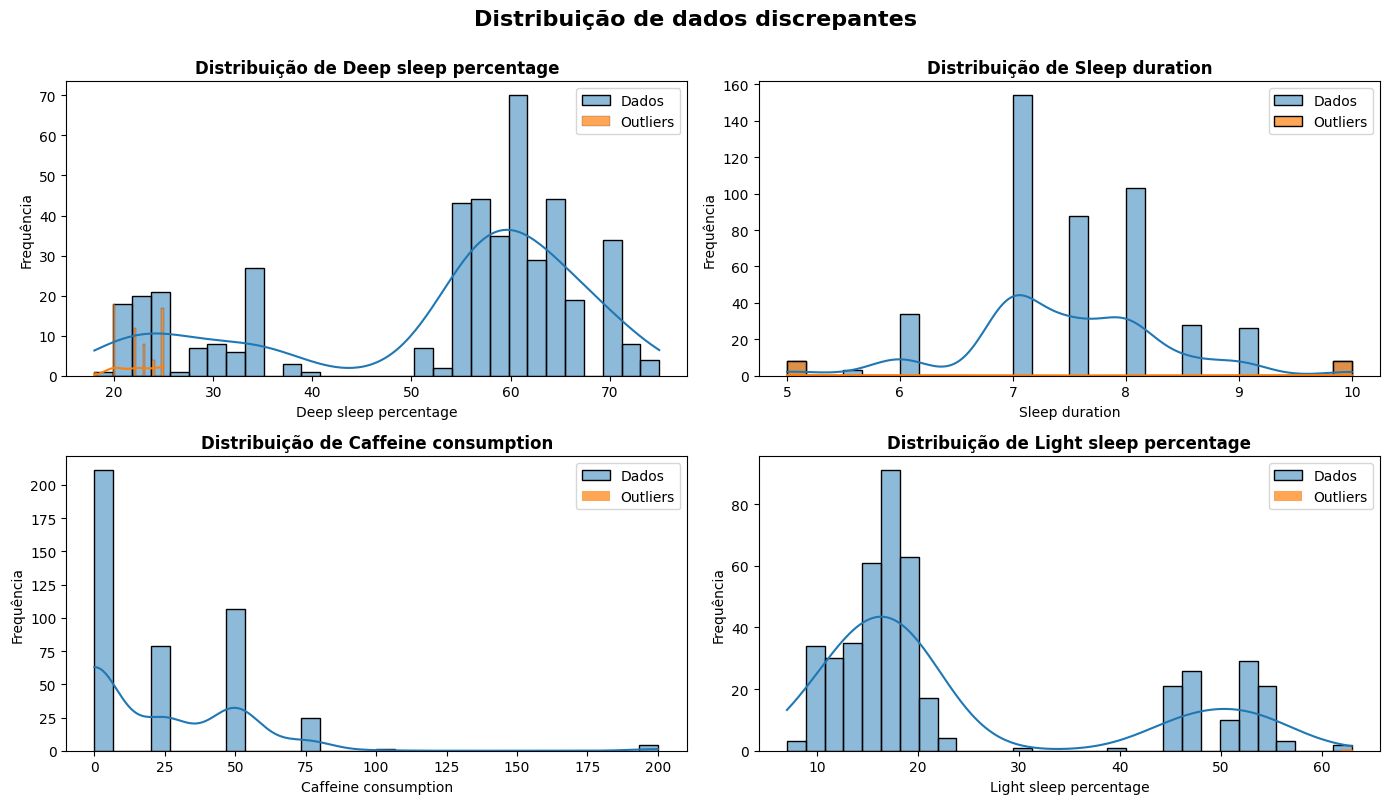

In [102]:
# Identificação de outliers usando o método do Intervalo Interquantil (IQR)

numeric_df = df.select_dtypes(include=[np.number])
factor = 1.5

def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    return (data < lower_bound) | (data > upper_bound)

# Aplicando a função a todas as colunas numéricas

outliers = numeric_df.apply(detect_outliers_iqr)

# Filtrando os dados para mostrar apenas os outliers

outliers_summary = outliers.sum().sort_values(ascending=False)
outliers_summary = outliers_summary[outliers_summary > 0]
outliers_data = numeric_df.loc[:, outliers_summary.index]
display(Markdown("*Número de Outliers por Coluna:* \n"))
display(outliers_summary)
print("\n")
display(outliers_data.head())
print("\n")

# Visualização gráfica

colors = ['#1f77b4', '#ff7f0e']
num_cols = outliers_data.shape[1]
num_rows = (num_cols + 1) // 2 
fig = plt.figure(figsize=(14, num_rows * 4))

fig.suptitle('Distribuição de dados discrepantes', fontweight='bold', fontsize=16, y=1)

for i, column in enumerate(outliers_data.columns, 1):
    plt.subplot(num_rows, 2, i)
    sns.histplot(numeric_df[column], bins=30, kde=True, color=colors[0], label='Dados')
    sns.histplot(numeric_df[column][outliers[column]], bins=30, kde=True, color=colors[1], label='Outliers', alpha=0.7)
    plt.title(f'Distribuição de {column}', fontsize=12, fontweight='bold')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.legend()

plt.tight_layout()
plt.show()

* Foram detectados outliers nas colunas numéricas do conjunto de dados usando o Método do Intervalo Interquantil (IQR).

* O cálculo do IQR revelou a presença de **82** outliers distribuídos entre as variáveis`Sleep duration`, `Deep sleep percentage`, `Light sleep percentage` e `Caffeine consumption`.

* A variável `Deep sleep percentage` possui o maior número de valores discrepantes, **60** ao todo, seguido de `Sleep duration`, com **16**, `Caffeine consumption`, com **4**, e `Light sleep percentage`, com **2**.

* Esses outliers foram visualizados graficamente para identificar padrões e impactos nos dados.

### **2. Padronização das Variáveis**

#### **2.1. Conversão de Variáveis Categóricas**

In [103]:
# Conversão De Variaveis Categóricas

df['Gender'] = df['Gender'].astype('category')
df['Smoking status'] = df['Smoking status'].astype('category')

print("Tipos dos dados após conversão: /n")
print(df.dtypes)

Tipos dos dados após conversão: /n
ID                           int64
Age                          int64
Gender                    category
Bedtime                     object
Wakeup time                 object
Sleep duration             float64
Sleep efficiency           float64
REM sleep percentage         int64
Deep sleep percentage        int64
Light sleep percentage       int64
Awakenings                 float64
Caffeine consumption       float64
Alcohol consumption        float64
Smoking status            category
Exercise frequency         float64
dtype: object


* Conversão das colunas `Gender` e `Smoking status` do conjunto de dados do tipo de dado `object` para o tipo `category`, sendo este mais eficiente para variáveis categóricas com um número limitado de valores distintos.

* Após a conversão, são apresentados os tipos de dado das colunas do conjunto de dados.

#### **2.2. Conversão e Separação de Variáveis de Tempo**

In [104]:
# Convertendo as colunas para datetime

df['Bedtime'] = pd.to_datetime(df['Bedtime'], format='%Y-%m-%d %H:%M:%S')
df['Wakeup time']= pd.to_datetime(df['Wakeup time'], format='%Y-%m-%d %H:%M:%S')

# Extraindo apenas a hora

df['bedtime_hour'] = df['Bedtime'].dt.hour
df['wakeup_hour']= df['Wakeup time'].dt.hour

# Aplicando a conversão cíclica

df['bedtime_hour_sin'] = np.sin(df['bedtime_hour'] * (2. * np.pi / 24))
df['bedtime_hour_cos'] = np.cos(df['bedtime_hour'] * (2. * np.pi / 24))

df['wakeup_hour_sin'] = np.sin(df['wakeup_hour'] * (2. * np.pi / 24))
df['wakeup_hour_cos'] = np.cos(df['wakeup_hour'] * (2. * np.pi / 24))

# Removendo as colunas originais de 'Bedtime' e 'Wakeup time', e também as colunas 'bedtime_hour' e 'wakeup_hour'
df = df.drop(columns=['Bedtime', 'Wakeup time', 'bedtime_hour', 'wakeup_hour'])

display(df.head())

,ID,Age,Gender,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency,bedtime_hour_sin,bedtime_hour_cos,wakeup_hour_sin,wakeup_hour_cos
0,1,65,Female,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0,0.258819,0.965926,0.965926,-0.258819
1,2,69,Male,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0,0.500000,0.866025,0.707107,-0.707107
2,3,40,Female,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0,-0.707107,0.707107,0.965926,0.258819
3,4,40,Female,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0,0.500000,0.866025,0.866025,-0.500000
4,5,57,Male,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0,0.258819,0.965926,0.707107,-0.707107


* Conversão das colunas `Bedtime` e `Wakeup time` para o tipo **datetime**, extraindo somente as colunas de hora, tendo em vista que as datas se referem somente ao período do estudo de eficiência do sono, portanto, não sendo relevante para o modelo.

* Extração das horas, gerando as colunas `bedtime_hour` e `wakeup_hour`.

* Conversão cíclica das variáveis `bedtime_hour` e `wakeup_hour` usando as funções seno e cosseno para mapear a natureza cíclica da hora.

* Por fim, as colunas originais `Bedtime` e `Wakeup time`, assim como, as colunas criadas `bedtime_hour` e `wakeup_hour` foram removidas do dataframe.

#### **2.3. Conversão de Unidades: Onças para Gramas na Coluna de `Alcohol consumption`**

In [105]:
# Conversão De Unidades

def oz_to_g(oz):
    return oz * 28.3495

# Aplicando a conversão na coluna 'Alcohol consumption'
df['alcohol_consumption_g'] = df['Alcohol consumption'].apply(oz_to_g)
df = df.drop(columns=['Alcohol consumption'])

display(df.head().round(2))

,ID,Age,Gender,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Smoking status,Exercise frequency,bedtime_hour_sin,bedtime_hour_cos,wakeup_hour_sin,wakeup_hour_cos,alcohol_consumption_g
0,1,65,Female,6.0,0.88,18,70,12,0.0,0.0,Yes,3.0,0.26,0.97,0.97,-0.26,0.00
1,2,69,Male,7.0,0.66,19,28,53,3.0,0.0,Yes,3.0,0.50,0.87,0.71,-0.71,85.05
2,3,40,Female,8.0,0.89,20,70,10,1.0,0.0,No,3.0,-0.71,0.71,0.97,0.26,0.00
3,4,40,Female,6.0,0.51,23,25,52,3.0,50.0,Yes,1.0,0.50,0.87,0.87,-0.50,141.75
4,5,57,Male,8.0,0.76,27,55,18,3.0,0.0,No,3.0,0.26,0.97,0.71,-0.71,85.05


* Conversão da unidade onça (oz) para grama (g) para padronização e melhor precisão das unidades de medida. A conversão foi aplicada na coluna `Alcohol consumption` e o resultado armazenado em uma nova coluna: `alcohol_consumption_g`.

* Em seguida, a coluna original Alcohol consumption foi removida.

#### **2.4. Excluindo colunas desnecessárias**

In [106]:
# Exclusão da coluna 'ID' do conjunto de dados

df = df.drop(columns=['ID'])

# Exclusão das colunas 'ID', 'Bedtime' e 'Wakeup time' do dicionário de dados

variables_to_exclude = ['ID', 'Bedtime', 'Wakeup time']
df_dict = df_dict[~df_dict['variavel'].isin(variables_to_exclude)]

* Excluída a coluna `ID` do conjunto de dados.

* Excluídas as colunas `ID`, `Bedtime` e `Wakeup time` do dicionário de dados.

* Tais colunas foram excluídas, tendo em vista que não serem determinantes para o modelo.

#### **2.5. Renomeando colunas**

In [107]:
# Renomeando a coluna Caffeine consumption para incluir a unidade de medida em mg

df.rename(columns={
   'Caffeine consumption': 'caffeine_consumption_mg', 
}, inplace=True)

# Renomeando todas as colunas no padrão snake_case
df.columns = [col.replace(' ', '_').lower() for col in df.columns]

display(df.head())

,age,gender,sleep_duration,sleep_efficiency,rem_sleep_percentage,deep_sleep_percentage,light_sleep_percentage,awakenings,caffeine_consumption_mg,smoking_status,exercise_frequency,bedtime_hour_sin,bedtime_hour_cos,wakeup_hour_sin,wakeup_hour_cos,alcohol_consumption_g
0,65,Female,6.0,0.88,18,70,12,0.0,0.0,Yes,3.0,0.258819,0.965926,0.965926,-0.258819,0.0000
1,69,Male,7.0,0.66,19,28,53,3.0,0.0,Yes,3.0,0.500000,0.866025,0.707107,-0.707107,85.0485
2,40,Female,8.0,0.89,20,70,10,1.0,0.0,No,3.0,-0.707107,0.707107,0.965926,0.258819,0.0000
3,40,Female,6.0,0.51,23,25,52,3.0,50.0,Yes,1.0,0.500000,0.866025,0.866025,-0.500000,141.7475
4,57,Male,8.0,0.76,27,55,18,3.0,0.0,No,3.0,0.258819,0.965926,0.707107,-0.707107,85.0485


* Formatação das variáveis com espaços ou letras maiúsculas para o padrão snake_case do Python, caracterizado pelo uso de letras minúsculas e underline, a fim de padronizar o nome das variáveis.

#### **2.6. Atualização do dicionário de dados**

In [108]:
# Criando as novas entradas para o dicionário de dados

new_columns = pd.DataFrame({
    'variavel': ['bedtime_hour_sin', 'bedtime_hour_cos', 'wakeup_hour_sin', 'wakeup_hour_cos'],
    'descricao': [
        'Seno da hora de ir para a cama (representação cíclica)',
        'Cosseno da hora de ir para a cama (representação cíclica)',
        'Seno da hora de acordar (representação cíclica)',
        'Cosseno da hora de acordar (representação cíclica)'
    ],
    'tipo': ['quantitativa', 'quantitativa', 'quantitativa', 'quantitativa'],
    'subtipo': ['contínua', 'contínua', 'contínua', 'contínua']
})

df_dict = pd.concat([df_dict, new_columns], ignore_index=True)

# Substituindo os nomes das variáveis no dicionário de dados

df_dict['variavel'] = df_dict['variavel'].str.replace(' ', '_').str.lower()

df_dict.replace({
      'caffeine_consumption': 'caffeine_consumption_mg', 
      'alcohol_consumption': 'alcohol_consumption_g',
}, inplace=True)

display(HTML(df_dict.to_html(index=False)))
display(Markdown(
    "---\n"
    "O dicionário de dados atualizado possui **16 variáveis**, sendo elas:\n" 
    "* **8** quatitativas discretas\n"
    "* **6** quantitativas contínuas\n" 
    "* **2** qualitativas nominais"
    "\n\n"
    "---"
))

variavel,descrição,tipo,subtipo,descricao
age,Idade do indivíduo em anos.,quantitativa,discreta,NaN
gender,Gênero do indivíduo.,qualitativa,nominal,NaN
sleep_duration,Duração total do sono do indivíduo em horas,quantitativa,contínua,NaN
sleep_efficiency,Eficiência do sono do indivíduo,quantitativa,contínua,NaN
rem_sleep_percentage,Percentual de sono REM (Rapid Eye Movement) do indivíduo em relação ao tempo total de sono,quantitativa,discreta,NaN
deep_sleep_percentage,Percentual de sono profundo do indivíduo em relação ao tempo total de sono,quantitativa,discreta,NaN
light_sleep_percentage,Percentual de sono leve do indivíduo em relação ao tempo total de sono.,quantitativa,discreta,NaN
awakenings,Número de vezes que o indivíduo despertou durante o período de sono,quantitativa,discreta,NaN
caffeine_consumption_mg,Quantidade de cafeína consumida pelo indivíduo em miligramas (mg) durante o dia,quantitativa,discreta,NaN
alcohol_consumption_g,Quantidade de álcool consumida pelo indivíduo em gramas (g) durante o dia,quantitativa,discreta,NaN


---
O dicionário de dados atualizado possui **16 variáveis**, sendo elas:
* **8** quatitativas discretas
* **6** quantitativas contínuas
* **2** qualitativas nominais

---

### **3. Preparação de dados**

Nesta seção, serão realizadas a preparação de dados com a separação da variáveis alvo e variáveis preditoras, o tratamento de dados faltantes e discrepantes, a normalização e a codificação em um pipeline de pré-processamento de dados.

#### **3.1. Preparação das Variáveis para Análise**

In [109]:
# Variável alvo
target_column = 'sleep_efficiency'

# Variáveis Nominais
nominal_columns = (
    df_dict
    .query("subtipo == 'nominal' and variavel != @target_column")
    .variavel
    .to_list()
)

# Variáveis Discretas
discrete_columns = (
    df_dict
    .query("subtipo == 'discreta' and variavel != @target_column")
    .variavel
    .to_list()
)

# Variáveis Contínuas
continuous_columns = (
    df_dict
    .query("subtipo == 'contínua' and variavel != @target_column")
    .variavel
    .to_list()
)
display(Markdown(
    f"- **Variável-alvo:** {target_column} \n\n"
    f"- **Variáveis qualitativas nominais:** {nominal_columns} \n"    
    f"- **Variáveis quantitativas discretas:** {discrete_columns} \n" 
    f"- **Variáveis quantitativas contínuas:** {continuous_columns} \n"
    "---"
))

# Isolando a variável-alvo das variáveis preditoras
X = df.drop(columns=[target_column], axis=1)
y = df[target_column]

- **Variável-alvo:** sleep_efficiency 

- **Variáveis qualitativas nominais:** ['gender', 'smoking_status'] 
- **Variáveis quantitativas discretas:** ['age', 'rem_sleep_percentage', 'deep_sleep_percentage', 'light_sleep_percentage', 'awakenings', 'caffeine_consumption_mg', 'alcohol_consumption_g', 'exercise_frequency'] 
- **Variáveis quantitativas contínuas:** ['sleep_duration', 'bedtime_hour_sin', 'bedtime_hour_cos', 'wakeup_hour_sin', 'wakeup_hour_cos'] 
---

#### **3.2. Tratamento de outliers**

In [110]:
# Tratamento de outliers pelo Método de Capping

# Classe para aplicar o Capping
class CappingOutliers(BaseEstimator, TransformerMixin):
    def __init__(self, lower_percentile=5, upper_percentile=95):
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_capped = X.copy()
        for col in range(X_capped.shape[1]):
            lower_bound = np.percentile(X_capped[:, col], self.lower_percentile)
            upper_bound = np.percentile(X_capped[:, col], self.upper_percentile)
            X_capped[:, col] = np.clip(X_capped[:, col], lower_bound, upper_bound)
        return X_capped

* Para o tratamento de outliers, foi utilizado o **Método de Capping (ou winsorizing)**. Esta técnica limita os valores extremos dos dados a intervalos definidos por percentis, tipicamente entre 5% e 95%.

* Valores abaixo do limite inferior de 5% são substituídos por esse limite inferior, enquanto valores acima do limite superior de 95% são ajustados para o limite superior. Essa abordagem reduz a influência dos outliers nos modelos de machine learning e minimiza as distorções nos dados.

#### **3.3. Pipeline de pré-processamento de dados**

In [111]:
# Tratamento de dados faltantes e discrepantes, codificação e normalização

# Pipeline para variáveis nominais
nominal_preprocessor = Pipeline([
    ('missing', SimpleImputer(strategy='most_frequent')), # Tratamento de dados faltantes
    ('encoding', OneHotEncoder(sparse_output=False, drop='first')), # Codificação de variáveis
])

# Pipeline para variáveis discretas
discrete_preprocessor = Pipeline([
    ('missing', SimpleImputer(strategy='median')), # Tratamento de dados faltantes
    ('capping', CappingOutliers()), # Tratamento de outliers
    ('normalization', StandardScaler()) # Normalização de dados 
])

# Pipeline para variáveis contínuas
continuous_preprocessor = Pipeline([
    ('missing', SimpleImputer(strategy='median')), # Tratamento de dados faltantes
    ('capping', CappingOutliers()), # Tratamento de outliers
    ('normalization', StandardScaler()) # Normalização de dados 
])

# Combinação dos pipelines em um ColumnTransformer
preprocessor = ColumnTransformer([
    ('nominal', nominal_preprocessor, nominal_columns),
    ('discrete', discrete_preprocessor, discrete_columns),
    ('continuous', continuous_preprocessor, continuous_columns),
])

* Neste processo de preparação de dados, foi criado um pipeline para cada tipo de variável: nominais, discretas e contínuas. 

* Para variáveis nominais, os dados faltantes foram tratados utilizando a imputação pela moda, seguida pela codificação das variáveis com OneHotEncoder. 

* Para variáveis discretas e contínuas, os dados faltantes foram imputados pela mediana, seguido pelo tratamento de outliers através de um método de capping, e, por fim, os dados foram normalizados utilizando StandardScaler. 

* Esses pipelines foram combinados em um `ColumnTransformer` para aplicar as transformações adequadas a cada tipo de variável de forma integrada.

In [112]:
# Aplicando o pipeline de pré-processamento aos dados X
X_transformed = preprocessor.fit_transform(X)
X_transformed.shape

(452, 15)

* O pipeline de pré-processamento foi aplicado aos dados `X` para tratar dados faltantes, codificar variáveis, e normalizar e tratar outliers, resultando em uma matriz transformada com novas dimensões.

In [113]:
# Apresentando o pré-processamento dos dados X

display(X_transformed)

array([[ 0.        ,  1.        ,  1.66055508, ...,  0.66026388,
         0.72209977, -0.12175529],
       [ 1.        ,  1.        ,  1.66055508, ..., -0.33917349,
        -0.97132271, -1.13124595],
       [ 0.        ,  0.        , -0.02503885, ..., -1.92904877,
         0.72209977,  1.04390413],
       ...,
       [ 0.        ,  1.        , -0.02503885, ...,  0.66026388,
         0.72209977, -0.12175529],
       [ 1.        ,  0.        ,  0.37629304, ..., -1.92904877,
         0.06846309,  1.58701496],
       [ 1.        ,  0.        , -1.55010002, ..., -0.33917349,
        -2.32639794, -1.48911179]])

* **Pipeline de variáveis nominais:** Inclui a imputação de valores faltantes pela moda, codificação das variáveis com **One-Hot Encoder**. O método de **Dummy Encoding** é utilizado, excluindo a primeira categoria para evitar multicolinearidade.

* **Pipeline de variáveis contínuas e discretas:** Inclui a imputação de valores faltantes pela mediana, o tratamento de outliers pelo **Método de Capping** e a normalização com o **Standard Scaler**.

* **Combinação dos pipelines:** Ambos os pipelines foram combinados em um **ColumnTransformer**, que aplica o pré-processamento adequado a cada grupo de colunas pré-estabelecido.

#### **3.4. Verificação de dados após o pré-processamento**

**Verificação de dados faltantes ou nulos**

In [114]:
# Verificando se ainda existem dados faltantes ou nulos após a etapa de pré-processamento

display(Markdown("*Número de dados faltantes após o pré-processamento:* \n"))
np.isnan(X_transformed).sum()

*Número de dados faltantes após o pré-processamento:* 


0

**Verificação de outliers**

In [115]:
# Verificando se ainda existem dados discrepantes após a etapa de pré-processamento

def detect_outliers(data, column_names, threshold=3):
    outliers_info = {}
    z_scores = np.abs(stats.zscore(data))
    for i, column_name in enumerate(column_names):
        outliers = (z_scores[:, i] > threshold)
        outliers_info[column_name] = np.sum(outliers)
    return outliers_info

# Lista dos nomes das colunas originais, incluindo as colunas contínuas e discretas

column_names = continuous_columns + discrete_columns

# Aplicando a detecção de outliers com Z-Score Ajustado

outliers = detect_outliers(X_transformed, column_names)

# Exibindo o número de outliers por coluna

display(Markdown("*Número de outliers após o pré-processamento:*\n"))
for column, count in outliers.items():
    print(f"{column}: {count}")

*Número de outliers após o pré-processamento:*


sleep_duration: 0
bedtime_hour_sin: 0
bedtime_hour_cos: 0
wakeup_hour_sin: 0
wakeup_hour_cos: 0
age: 0
rem_sleep_percentage: 0
deep_sleep_percentage: 0
light_sleep_percentage: 0
awakenings: 0
caffeine_consumption_mg: 0
alcohol_consumption_g: 0
exercise_frequency: 0


* Após a transformação, foi confirmada a ausência de dados faltantes, com a soma de valores `NaN` resultando em **0**.

* Por meio do método **Z-score**, foi observada também a ausência de valores discrepantes após a etapa de pré-processamento.

### **4. Modelagem Preditiva**

#### **4.1 Seleção de Modelos**

Vamos realizar a avaliação de quatro modelos de aprendizado de máquina utilizando um processo de validação para identificar qual deles apresenta o melhor desempenho no conjunto de dados analisado em questão. Os modelos que serão analisados incluem:

**1. K-Nearest Neighbors (KNN)**: Este modelo classifica os dados com base na proximidade dos vizinhos mais próximos, utilizando a distância entre pontos para fazer previsões.

**2. Support Vector Machine (SVM)**: Um algoritmo que tenta encontrar a melhor linha ou hiperplano que separa as diferentes classes no espaço de características.

**3. Decision Tree**: Este modelo organiza as decisões em uma estrutura hierárquica, onde cada nó representa uma decisão com base em um atributo específico, facilitando a categorização ou previsão.

**4. Random Forest**: Uma combinação de várias árvores de decisão, onde cada árvore contribui para a decisão final, aumentando a precisão e reduzindo a chance de overfitting.

Para cada um desses modelos, experimentaremos diferentes conjuntos de hiperparâmetros, a fim de encontrar a configuração mais eficaz.

As métricas que utilizaremos para avaliar a performance dos modelos são:

- **Acurácia (Accuracy)**: A taxa de previsões corretas em relação ao total de previsões, indicando a eficácia global do modelo.
- **Precisão (Precision)**: A porcentagem de verdadeiros positivos entre todos os casos que o modelo identificou como positivos, refletindo a qualidade das previsões positivas.
- **Recall**: A porcentagem de verdadeiros positivos em relação ao total de casos que realmente eram positivos, medindo a capacidade do modelo de detectar todos os casos positivos.
- **F1-score**: Uma média ponderada entre precisão e recall, que é especialmente útil quando as classes estão desbalanceadas, pois leva em conta tanto os falsos positivos quanto os falsos negativos.

Essas métricas nos permitirão comparar os modelos de forma abrangente, identificando qual deles é mais adequado para o conjunto de dados em análise.

In [116]:
# Configurações do experimento
n_splits_comparative_analysis = 10
n_folds_grid_search = 5
test_size = 0.2
random_state = 42
# scoring = 'accuracy'
# metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
scoring = make_scorer(mean_squared_error, greater_is_better=False)
metrics = ['neg_mean_squared_error', 'r2']

# Configurações dos modelos de regressão
models = [
    ('Linear Regression', LinearRegression(), {}),
    ('Ridge Regression', Ridge(), {
        'alpha': [0.1, 1.0, 10.0, 100.0]
    }),
    ('Lasso Regression', Lasso(), {
        'alpha': [0.01, 0.1, 1.0, 10.0]
    }),
    ('Random Forest Regressor', RandomForestRegressor(random_state=random_state), {
        'n_estimators': [10, 50, 100],
        'max_depth': [3, 6, 8],
    }),
]

In [118]:
results = pd.DataFrame({})
cross_validate_grid_search = KFold(n_splits=n_folds_grid_search)
cross_validate_comparative_analysis = ShuffleSplit(n_splits=n_splits_comparative_analysis, test_size=test_size, random_state=random_state)

for model_name, model_object, model_parameters in models:
    print(f"running {model_name}...")
    model_grid_search = GridSearchCV(
        estimator=model_object,
        param_grid=model_parameters,
        scoring=scoring,
        n_jobs=-1,
        cv=cross_validate_grid_search
    )
    approach = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model_grid_search)
    ])
    scores = cross_validate(
        estimator=approach,
        X=X,
        y=y,
        cv=cross_validate_comparative_analysis,
        n_jobs=-1,
        scoring=metrics
    )
    scores['model_name'] = [model_name] * n_splits_comparative_analysis  
    display(pd.DataFrame(scores).drop(columns=['model_name']).agg(['mean', 'std']))
    results = pd.concat([results, pd.DataFrame(scores)], ignore_index=True)

running Linear Regression...


,fit_time,score_time,test_neg_mean_squared_error,test_r2
mean,1.035719,0.373952,-0.003685,0.803391
std,0.188618,0.141688,0.000415,0.030598


running Ridge Regression...


,fit_time,score_time,test_neg_mean_squared_error,test_r2
mean,1.704742,0.295739,-0.003648,0.805381
std,0.277145,0.110066,0.000388,0.029406


running Lasso Regression...


,fit_time,score_time,test_neg_mean_squared_error,test_r2
mean,1.617695,0.270819,-0.004256,0.772643
std,0.217894,0.062434,0.000410,0.035300


running Random Forest Regressor...


,fit_time,score_time,test_neg_mean_squared_error,test_r2
mean,69.569504,0.335915,-0.002494,0.866401
std,8.492012,0.201584,0.000416,0.028522


In [119]:
def highlight_best(s, props=''):
    if s.name[1] != 'std':
        if s.name[0].endswith('time'):
            return np.where(s == np.nanmin(s.values), props, '')
        return np.where(s == np.nanmax(s.values), props, '')

display(Markdown("### 4.2 Resultados gerais"))
(
    results
    .groupby('model_name')
    .agg(['mean', 'std']).T
    .style
    .apply(highlight_best, props='color:white;background-color:gray;font-weight: bold;', axis=1)
    .set_table_styles([{'selector': 'td', 'props': 'text-align: center;'}])
)

### 4.2 Resultados gerais

#### **4.3. Persistência do Modelo**

In [120]:
#Obtem o modelo e os parametros ganhadores
model_name, model_object, model_parameters  = [foo for foo in models if foo[0] == "Random Forest Regressor"][0] 


model_grid_search = GridSearchCV(
        estimator=model_object,
        param_grid=model_parameters,
        scoring=scoring,
        n_jobs=-1,
        cv=cross_validate_grid_search
    )

approach = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_grid_search)
])

approach.fit(X, y) #Seleciona o approach

print(f"Hiper parâmetros do modelo: {approach.steps[1][1].best_params_}")

Hiper parâmetros do modelo: {'max_depth': 6, 'n_estimators': 10}


### **5. Validação dos Modelos**